In [ ]:
from google.colab import drive
drive.mount('/drive')

Mounted at /drive


In [ ]:
import glob
import pandas as pd
import random

In [ ]:
result["Weighted_average"] = round(((result["Optimistic"] + (4*result["Most_likely"]) + result["Pessimistic"])/6), 2)
result["Standard_deviation"] = round(((result["Pessimistic"] - result["Optimistic"])/6), 2)
result["Risk_factor"] = round((result["Standard_deviation"]/result["Weighted_average"]), 2)
result["Standard_confidence"] = result["Weighted_average"]
result["High_confidence"] = round((result["Weighted_average"] + (0.53 * result["Standard_deviation"])), 2)
result["Higher_confidence"] = round((result["Weighted_average"] + (1.28 * result["Standard_deviation"])), 2)
result["Highest_confidence"] = round((result["Weighted_average"] + (2.33 * result["Standard_deviation"])), 2)
result["Final_estimate"] = round((result["Highest_confidence"]), 1)

In [ ]:
result["Variance"] = round(((6*result["Pessimistic"] - result["Optimistic"])**2), 2)

In [ ]:
result.head(3)

In [ ]:
result.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/input_data.csv')

In [ ]:
result["Final_estimate"] = result["Final_estimate"].astype(int)

In [ ]:
### creating model now
df_res = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/input_data.csv')

In [ ]:
df_res.shape

(6435, 20)

In [ ]:
df_res.head(2)

In [ ]:
df_res = df_res.rename(columns={'Label': 'Task_label'})

In [ ]:
df_res['Final_estimate'] = np.where((df_res['Risk_factor'] >= 0) & (df_res['Risk_factor'] <= 0.05), df_res['Standard_confidence'], df_res['Final_estimate'])
df_res['Final_estimate'] = np.where((df_res['Risk_factor'] > 0.05) & (df_res['Risk_factor'] <= 0.1), df_res['High_confidence'], df_res['Final_estimate'])
df_res['Final_estimate'] = np.where((df_res['Risk_factor'] > 0.1) & (df_res['Risk_factor'] <= 0.15), df_res['Higher_confidence'], df_res['Final_estimate'])

In [ ]:
df_res["Final_estimate"] = df_res["Final_estimate"].astype(int)

## **One Hot Encoding**

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

Features

In [ ]:
#Task_label
tl_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
tl_train = train_df_res["Task_label"].to_numpy().reshape(-1,1)
tl_test = test_df_res["Task_label"].to_numpy().reshape(-1,1)
tl_enc.fit(tl_train)
len_tl_enc = tl_enc.categories_[0].shape
print(len_tl_enc)

tl_train = tl_enc.transform(tl_train)
tl_test = tl_enc.transform(tl_test)
print(tl_train.shape, tl_test.shape)

(4,)
(5791, 4) (644, 4)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
#Planned_estimate
pe_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
pe_train = train_df_res["Planned_estimate"].to_numpy().reshape(-1,1)
pe_test = test_df_res["Planned_estimate"].to_numpy().reshape(-1,1)
pe_enc.fit(pe_train)
len_pe_enc = pe_enc.categories_[0].shape
print(len_pe_enc)

pe_train = pe_enc.transform(pe_train)
pe_test = pe_enc.transform(pe_test)
print(pe_train.shape, pe_test.shape)

(15,)
(5791, 15) (644, 15)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
#Final_estimate
fe_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
fe_train = train_df_res["Final_estimate"].to_numpy().reshape(-1,1)
fe_test = test_df_res["Final_estimate"].to_numpy().reshape(-1,1)
fe_enc.fit(fe_train)
len_fe_enc = fe_enc.categories_[0].shape
print(len_fe_enc)

fe_train = fe_enc.transform(fe_train)
fe_test = fe_enc.transform(fe_test)
print(fe_train.shape, fe_test.shape)

(28,)
(5791, 28) (644, 28)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
#Optimistic_estimate
oe_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
oe_train = train_df_res["Optimistic"].to_numpy().reshape(-1,1)
oe_test = test_df_res["Optimistic"].to_numpy().reshape(-1,1)
oe_enc.fit(oe_train)
len_oe_enc = oe_enc.categories_[0].shape
print(len_oe_enc)

oe_train = oe_enc.transform(oe_train)
oe_test = oe_enc.transform(oe_test)
print(oe_train.shape, oe_test.shape)

(23,)
(5791, 23) (644, 23)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
#Most_likely_estimate
mle_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
mle_train = train_df_res["Most_likely"].to_numpy().reshape(-1,1)
mle_test = test_df_res["Most_likely"].to_numpy().reshape(-1,1)
mle_enc.fit(mle_train)
len_mle_enc = mle_enc.categories_[0].shape
print(len_mle_enc)

mle_train = mle_enc.transform(mle_train)
mle_test = mle_enc.transform(mle_test)
print(mle_train.shape, mle_test.shape)

(22,)
(5791, 22) (644, 22)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
#Pessimistic_estimate
pes_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
pes_train = train_df_res["Pessimistic"].to_numpy().reshape(-1,1)
pes_test = test_df_res["Pessimistic"].to_numpy().reshape(-1,1)
pes_enc.fit(pes_train)
len_pes_enc = pes_enc.categories_[0].shape
print(len_pes_enc)

pes_train = pes_enc.transform(pes_train)
pes_test = pes_enc.transform(pes_test)
print(pes_train.shape, pes_test.shape)

(29,)
(5791, 29) (644, 29)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Label

In [ ]:
#Actual_estimate
ae_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
ae_train = train_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_test = test_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_enc.fit(ae_train)
len_ae_enc = ae_enc.categories_[0].shape
print(len_ae_enc)

ae_train = ae_enc.transform(ae_train)
ae_test = ae_enc.transform(ae_test)
print(ae_train.shape, ae_test.shape)

(26,)
(5791, 26) (644, 26)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## **Split Data**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_df_res, test_df_res = train_test_split(df_res, test_size=0.1, random_state=42, shuffle=True)

In [ ]:
test_df_res.shape

(644, 21)

In [ ]:
train_df_res.shape

(5791, 21)

In [ ]:
train_df_res.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/train_data.csv')

In [ ]:
test_df_res.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/test_df_res.csv')

In [ ]:
train_df_res = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/train_data.csv')
test_df_res = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/test_df_res.csv')

## **Gpt-2 tokenizer & pre-trained model**

In [ ]:
import tensorflow as tf

In [ ]:
from transformers import GPT2Tokenizer, TFGPT2Model

In [ ]:
class GPT:
    def __init__(self):
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.model = TFGPT2Model.from_pretrained('gpt2')

    def inp_vector(self, inp):
        encoded_inp = self.tokenizer(inp, return_tensors='tf')
        out = self.model(encoded_inp)
        vector = out[0].numpy()[0]
        return np.mean(vector, axis=0)

    def vectors(self, inps):
        feat_vectors = []
        for i in inps:
            if type(i) != 'str':
                i = "NA"
            feat_vectors.append(self.inp_vector(i))
        return np.array(feat_vectors)

gpt_model = GPT()

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFGPT2Model.

All the weights of TFGPT2Model were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFGPT2Model for predictions without further training.


## **Features Encoding**

Task Name

In [ ]:
# training embeddings
tn_train = gpt_model.vectors(train_df_res["Task_name"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_name_train.npy', tn_train)
print(type(tn_train))
print(tn_train.shape)

<class 'numpy.ndarray'>
(5791, 768)


In [ ]:
# testing embeddings
tn_test = gpt_model.vectors(test_df_res["Task_name"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_name_test.npy', tn_test)
print(type(tn_test))
print(tn_test.shape)

<class 'numpy.ndarray'>
(644, 768)


Task description

In [ ]:
# training embeddings
td_train = gpt_model.vectors(train_df_res["Task_description"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_desc_train.npy', td_train)
print(type(td_train))
print(td_train.shape)

<class 'numpy.ndarray'>
(5791, 768)


In [ ]:
# testing embeddings
td_test = gpt_model.vectors(test_df_res["Task_description"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_desc_test.npy', td_test)
print(type(td_test))
print(td_test.shape)

<class 'numpy.ndarray'>
(644, 768)


Task label

In [ ]:
# training embeddings
tl_train = gpt_model.vectors(train_df_res["Task_label"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_label_train.npy', tl_train)
print(type(tl_train))
print(tl_train.shape)

<class 'numpy.ndarray'>
(5791, 768)


In [ ]:
# testing embeddings
tl_test = gpt_model.vectors(test_df_res["Task_label"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/task_label_test.npy', tl_test)
print(type(tl_test))
print(tl_test.shape)

<class 'numpy.ndarray'>
(644, 768)


Planned estimate

In [ ]:
# training embeddings
pe_train = gpt_model.vectors(train_df_res["Planned_estimate"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/planned_est_train.npy', pe_train)
print(type(pe_train))
print(pe_train.shape)

<class 'numpy.ndarray'>
(5791, 768)


In [ ]:
# testing embeddings
pe_test = gpt_model.vectors(test_df_res["Planned_estimate"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/planned_est_test.npy', pe_test)
print(type(pe_test))
print(pe_test.shape)

<class 'numpy.ndarray'>
(644, 768)


Final estimate

In [ ]:
# training embeddings
fe_train = gpt_model.vectors(train_df_res["Final_estimate"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/final_est_train.npy', fe_train)
print(type(fe_train))
print(fe_train.shape)

<class 'numpy.ndarray'>
(5791, 768)


In [ ]:
# testing embeddings
fe_test = gpt_model.vectors(test_df_res["Final_estimate"])
np.save('../drive/MyDrive/Colab Notebooks/Estimates/final_est_test.npy', fe_test)
print(type(fe_test))
print(fe_test.shape)

<class 'numpy.ndarray'>
(644, 768)


## Load features

In [ ]:
# Load feature encodings - Task name, task description, task label, planned estimate & final estimate
tn_train = np.load('../drive/MyDrive/Colab Notebooks/Estimates/task_name_train.npy')
tn_test = np.load('../drive/MyDrive/Colab Notebooks/Estimates/task_name_test.npy')

td_train = np.load('../drive/MyDrive/Colab Notebooks/Estimates/task_desc_train.npy')
td_test = np.load('../drive/MyDrive/Colab Notebooks/Estimates/task_desc_test.npy')

# tl_train = np.load('../drive/MyDrive/Colab Notebooks/Estimates/task_label_train.npy')
# tl_test = np.load('../drive/MyDrive/Colab Notebooks/Estimates/task_label_test.npy')

# pe_train = np.load('../drive/MyDrive/Colab Notebooks/Estimates/planned_est_train.npy')
# pe_test = np.load('../drive/MyDrive/Colab Notebooks/Estimates/planned_est_test.npy')

# fe_train = np.load('../drive/MyDrive/Colab Notebooks/Estimates/final_est_train.npy')
# fe_test = np.load('../drive/MyDrive/Colab Notebooks/Estimates/final_est_test.npy')

## **Define NN Architecture**

In [ ]:
# Branch-1 Task name
inp1 = tf.keras.Input(shape=(768,), dtype=tf.int32, name="input_layer_1")
lay1 = tf.keras.layers.Dense(128, activation='relu')(inp1)

# Branch-2 Task description
inp2 = tf.keras.Input(shape=(768,), dtype=tf.int32, name="input_layer_2")
lay2 = tf.keras.layers.Dense(128, activation='relu')(inp2)

# Branch-3 Task label
inp3 = tf.keras.Input(shape=(4,), dtype=tf.int32, name="input_layer_3")
lay3 = tf.keras.layers.Dense(4, activation='relu')(inp3)

# Branch-4 Planned estimate
inp4 = tf.keras.Input(shape=(15,), dtype=tf.int32, name="input_layer_4")
lay4 = tf.keras.layers.Dense(16, activation='relu')(inp4)

# Branch-5 Final estimate
inp5 = tf.keras.Input(shape=(28,), dtype=tf.int32, name="input_layer_5")
lay5 = tf.keras.layers.Dense(32, activation='relu')(inp5)

# Branch-6 Optimistic estimate
inp6 = tf.keras.Input(shape=(23,), dtype=tf.int32, name="input_layer_6")
lay6 = tf.keras.layers.Dense(32, activation='relu')(inp6)

# Branch-7 Most Likely estimate
inp7 = tf.keras.Input(shape=(22,), dtype=tf.int32, name="input_layer_7")
lay7 = tf.keras.layers.Dense(32, activation='relu')(inp7)

# Branch-8 Pessimistic2 estimate
inp8 = tf.keras.Input(shape=(29,), dtype=tf.int32, name="input_layer_8")
lay8 = tf.keras.layers.Dense(32, activation='relu')(inp8)

# Concatenate Branch
out = tf.keras.layers.Concatenate()([lay1, lay2, lay3, lay4, lay5, lay6, lay7, lay8])
out = tf.keras.layers.Dense(384, activation='relu')(out)
out = tf.keras.layers.Dense(128, activation='relu')(out)
out = tf.keras.layers.Dense(26, activation='softmax')(out)

model = tf.keras.models.Model(inputs=[inp1, inp2, inp3, inp4, inp5, inp6, inp7, inp8], outputs=out)

In [ ]:
model.compile(tf.keras.optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer_1 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_2 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_3 (InputLayer)  [(None, 4)]                  0         []                            
                                                                                                  
 input_layer_4 (InputLayer)  [(None, 15)]                 0         []                            
                                                                                            

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint('model.h5', monitor='loss', save_best_only=True, verbose=1)

## **Model Training**

In [ ]:
train_sh = model.fit(
    [tn_train, td_train, tl_train, pe_train, fe_train, oe_train, mle_train, pes_train], ae_train,
    epochs=100,
    callbacks=[checkpoint],
    validation_data=([tn_test, td_test, tl_test, pe_test, fe_test, oe_test, mle_test, pes_test], ae_test),
    batch_size=32,
    verbose=1
)

Epoch 1/100
178/181 [============================>.] - ETA: 0s - loss: 1.4436 - accuracy: 0.4092
Epoch 1: loss improved from inf to 1.43619, saving model to model.h5
181/181 [==============================] - 6s 10ms/step - loss: 1.4362 - accuracy: 0.4110 - val_loss: 0.9262 - val_accuracy: 0.5062
Epoch 2/100
  7/181 [>.............................] - ETA: 1s - loss: 0.8847 - accuracy: 0.4821

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


174/181 [===========================>..] - ETA: 0s - loss: 0.8574 - accuracy: 0.5014
Epoch 2: loss improved from 1.43619 to 0.85522, saving model to model.h5
181/181 [==============================] - 2s 9ms/step - loss: 0.8552 - accuracy: 0.5022 - val_loss: 0.8238 - val_accuracy: 0.4783
Epoch 3/100
177/181 [============================>.] - ETA: 0s - loss: 0.8034 - accuracy: 0.4936
Epoch 3: loss improved from 0.85522 to 0.80224, saving model to model.h5
181/181 [==============================] - 2s 9ms/step - loss: 0.8022 - accuracy: 0.4940 - val_loss: 0.7825 - val_accuracy: 0.4829
Epoch 4/100
173/181 [===========================>..] - ETA: 0s - loss: 0.7725 - accuracy: 0.4926
Epoch 4: loss improved from 0.80224 to 0.77292, saving model to model.h5
181/181 [==============================] - 1s 6ms/step - loss: 0.7729 - accuracy: 0.4939 - val_loss: 0.7536 - val_accuracy: 0.4798
Epoch 5/100
174/181 [===========================>..] - ETA: 0s - loss: 0.7412 - accuracy: 0.5169
Epoch 5: los

In [ ]:
print(train_sh.history)
model.save('../drive/MyDrive/Colab Notebooks/Estimates/Model2/model2.h5')
results = model.evaluate([tn_test, td_test, tl_test, pe_test, fe_test, oe_test, mle_test, pes_test], ae_test, batch_size=16)

predictions = model.predict([tn_test, td_test, tl_test, pe_test, fe_test, oe_test, mle_test, pes_test])

print(predictions.shape)
print(ae_test.shape)

y_actual_label = test_df_res["Actual_estimate"]
y_pred_label = ae_enc.inverse_transform(predictions)
print(y_actual_label.shape, y_pred_label.shape)

test_df_res['Ai_estimate'] = y_pred_label
test_df_res.head(3)

{'loss': [1.4361903667449951, 0.8552202582359314, 0.8022449016571045, 0.7729154825210571, 0.7398351430892944, 0.7318689227104187, 0.7178186178207397, 0.7133063673973083, 0.7074418663978577, 0.700255274772644, 0.6939295530319214, 0.6938336491584778, 0.6889194250106812, 0.6873553395271301, 0.6892207860946655, 0.6803823709487915, 0.6823722124099731, 0.6814266443252563, 0.6791514754295349, 0.677760660648346, 0.67743319272995, 0.6773064136505127, 0.6762110590934753, 0.6770931482315063, 0.6757901310920715, 0.6761993169784546, 0.6739463210105896, 0.6716432571411133, 0.6735880970954895, 0.6702051758766174, 0.6728310585021973, 0.6731334924697876, 0.6715049147605896, 0.6744053363800049, 0.6709100008010864, 0.669404149055481, 0.6696654558181763, 0.6705676913261414, 0.6706187725067139, 0.6696828007698059, 0.669492244720459, 0.6686996817588806, 0.6689157485961914, 0.6682857871055603, 0.6686742305755615, 0.6688318848609924, 0.6669521927833557, 0.6685343384742737, 0.6663766503334045, 0.66863578557968

,Unnamed: 0.1,Unnamed: 0,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,...,Weighted_average,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance,Ai_estimate
0,2436,2262,[New Containers] Remove input/process dotted l...,Right now the flow container has a dashed line...,EST_BE,Medium,INT Sprint 1,16,16,15,...,15.83,0.17,0.01,15.83,15.92,16.05,16.23,15,6561,17
1,3361,3187,Studio support for new OAuth configuration,"As a Studio user, I will like to have support ...",EST_BE,Medium,INT Sprint 1,4,5,3,...,3.83,0.17,0.04,3.83,3.92,4.05,4.23,3,441,5
2,233,59,"migrate items from 562 get error dialog popup,...","1. start 562 tac, on configuration page select...",EST_BE,Medium,INT Sprint 1,4,4,3,...,4.00,0.33,0.08,4.00,4.17,4.42,4.77,4,729,5


In [ ]:
test_df_res.drop(test_df_res.columns[[0, 1]], axis=1, inplace=True)

In [ ]:
test_df_res.head(3)

,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,Pessimistic,Weighted_average,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance,Ai_estimate
0,[New Containers] Remove input/process dotted l...,Right now the flow container has a dashed line...,EST_BE,Medium,INT Sprint 1,16,16,15,16,16,15.83,0.17,0.01,15.83,15.92,16.05,16.23,15,6561,17
1,Studio support for new OAuth configuration,"As a Studio user, I will like to have support ...",EST_BE,Medium,INT Sprint 1,4,5,3,4,4,3.83,0.17,0.04,3.83,3.92,4.05,4.23,3,441,5
2,"migrate items from 562 get error dialog popup,...","1. start 562 tac, on configuration page select...",EST_BE,Medium,INT Sprint 1,4,4,3,4,5,4.00,0.33,0.08,4.00,4.17,4.42,4.77,4,729,5


In [ ]:
test_df_res.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/Model2/Model2_results.csv')

Text(0, 0.5, 'AI estimate')

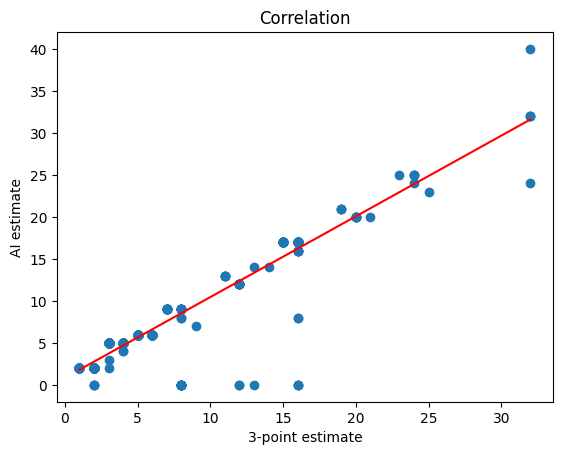

In [ ]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y = test_df_res['Ai_estimate']
x = test_df_res['Final_estimate']
correlation = y.corr(x)
correlation

# adds the title
plt.title('Correlation')

# plot the data
plt.scatter(x, y)

# fits the best fitting line to the data
plt.plot(np.unique(x),
		np.poly1d(np.polyfit(x, y, 1))
		(np.unique(x)), color='red')

# Labelling axes
plt.xlabel('3-point estimate')
plt.ylabel('AI estimate')

In [ ]:
# prepare testing data

In [ ]:
df_test = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/test_data.csv')

In [ ]:
df_test.shape

(21, 7)

In [ ]:
df_test.head(3)


,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate
0,Set up JDK and integrate with backend,Setting up the Java Development Kit in the pro...,EST_BE,Medium,ET Sprint 4,16,16
1,Set up environment and install packages,Setting up Python environment in AWS EC-2 Inst...,EST_INFRA,Medium,ET Sprint 4,4,4
2,"Create data preprocessing, feature engineering...",Data preprocessing - Data cleaning and transfo...,EST_AI,Medium,ET Sprint 4,8,9


In [ ]:
import numpy as np

In [ ]:
df_test["Optimistic"] = df_test["Planned_estimate"] + np.random.randint(0, 1, df_test.shape[0])
df_test["Most_likely"] = df_test["Planned_estimate"] + np.random.randint(0, 2, df_test.shape[0])
df_test["Pessimistic"] = df_test["Planned_estimate"] + np.random.randint(0, 3, df_test.shape[0])

In [ ]:
df_test["Weighted_average"] = round(((df_test["Optimistic"] + (4*df_test["Most_likely"]) + df_test["Pessimistic"])/6), 2)
df_test["Standard_deviation"] = round(((df_test["Pessimistic"] - df_test["Optimistic"])/6), 2)
df_test["Risk_factor"] = round((df_test["Standard_deviation"]/df_test["Weighted_average"]), 2)
df_test["Standard_confidence"] = df_test["Weighted_average"]
df_test["High_confidence"] = round((df_test["Weighted_average"] + (0.53 * df_test["Standard_deviation"])), 2)
df_test["Higher_confidence"] = round((df_test["Weighted_average"] + (1.28 * df_test["Standard_deviation"])), 2)
df_test["Highest_confidence"] = round((df_test["Weighted_average"] + (2.33 * df_test["Standard_deviation"])), 2)
df_test["Final_estimate"] = round((df_test["Highest_confidence"]), 1)
df_test["Variance"] = round(((6*df_test["Pessimistic"] - df_test["Optimistic"])**2), 2)
df_test['Final_estimate'] = np.where((df_test['Risk_factor'] >= 0) & (df_test['Risk_factor'] <= 0.05), df_test['Standard_confidence'], df_test['Final_estimate'])
df_test['Final_estimate'] = np.where((df_test['Risk_factor'] > 0.05) & (df_test['Risk_factor'] <= 0.1), df_test['High_confidence'], df_test['Final_estimate'])
df_test['Final_estimate'] = np.where((df_test['Risk_factor'] > 0.1) & (df_test['Risk_factor'] <= 0.15), df_test['Higher_confidence'], df_test['Final_estimate'])
df_test["Final_estimate"] = df_test["Final_estimate"].astype(int)


In [ ]:
df_test.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/test_data_complete.csv')

In [ ]:
### Start

In [ ]:
df_test = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/test_data_complete.csv')

In [ ]:
df_test.shape

(21, 20)

In [ ]:
df_test.head(3)

,Unnamed: 0,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,Pessimistic,Weighted_average,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance
0,0,Set up JDK and integrate with backend,Setting up the Java Development Kit in the pro...,EST_BE,Medium,ET Sprint 4,16,16,16,17,16,16.67,0.00,0.00,16.67,16.67,16.67,16.67,16,6400
1,1,Set up environment and install packages,Setting up Python environment in AWS EC-2 Inst...,EST_INFRA,Medium,ET Sprint 4,4,4,4,4,4,4.00,0.00,0.00,4.00,4.00,4.00,4.00,4,400
2,2,"Create data preprocessing, feature engineering...",Data preprocessing - Data cleaning and transfo...,EST_AI,Medium,ET Sprint 4,8,9,8,8,10,8.33,0.33,0.04,8.33,8.50,8.75,9.10,8,2704


In [ ]:
# Testing data encodings
tn_testdata = gpt_model.vectors(df_test["Task_name"])
print(type(tn_testdata))
print(tn_testdata.shape)

td_testdata = gpt_model.vectors(df_test["Task_description"])
print(type(td_testdata))
print(td_testdata.shape)

tl_testdata = df_test["Task_label"].to_numpy().reshape(-1,1)
tl_testdata = tl_enc.transform(tl_testdata)
print(tl_testdata.shape)

pe_testdata = df_test["Planned_estimate"].to_numpy().reshape(-1,1)
pe_testdata = pe_enc.transform(pe_testdata)
print(pe_testdata.shape)

fe_testdata = df_test["Final_estimate"].to_numpy().reshape(-1,1)
fe_testdata = fe_enc.transform(fe_testdata)
print(fe_testdata.shape)

oe_testdata = df_test["Optimistic"].to_numpy().reshape(-1,1)
oe_testdata = oe_enc.transform(oe_testdata)
print(oe_testdata.shape)

mle_testdata = df_test["Most_likely"].to_numpy().reshape(-1,1)
mle_testdata = mle_enc.transform(mle_testdata)
print(mle_testdata.shape)

pes_testdata = df_test["Pessimistic"].to_numpy().reshape(-1,1)
pes_testdata = pes_enc.transform(pes_testdata)
print(pes_testdata.shape)

<class 'numpy.ndarray'>
(21, 768)
<class 'numpy.ndarray'>
(21, 768)
(21, 4)
(21, 15)
(21, 28)
(21, 23)
(21, 22)
(21, 29)


In [ ]:
import tensorflow as tf

In [ ]:
model2 = tf.keras.models.load_model('../drive/MyDrive/Colab Notebooks/Estimates/Model2/model2.h5')
model2.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer_1 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_2 (InputLayer)  [(None, 768)]                0         []                            
                                                                                                  
 input_layer_3 (InputLayer)  [(None, 4)]                  0         []                            
                                                                                                  
 input_layer_4 (InputLayer)  [(None, 15)]                 0         []                            
                                                                                            

In [ ]:
### Not required

In [ ]:
from sklearn.preprocessing import OneHotEncoder

train_df_res = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/train_data.csv')
test_df_res = pd.read_csv('../drive/MyDrive/Colab Notebooks/Estimates/test_df_res.csv')

#Actual_estimate
ae_enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
ae_train = train_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_test = test_df_res["Actual_estimate"].to_numpy().reshape(-1,1)
ae_enc.fit(ae_train)
len_ae_enc = ae_enc.categories_[0].shape
print(len_ae_enc)

ae_train = ae_enc.transform(ae_train)
ae_test = ae_enc.transform(ae_test)
print(ae_train.shape, ae_test.shape)

(26,)
(5791, 26) (644, 26)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
ae_testdata = df_test["Actual_estimate"].to_numpy().reshape(-1,1)
ae_testdata = ae_enc.transform(ae_testdata)
print(ae_testdata.shape)

(21, 26)


In [ ]:
predictions = model2.predict([tn_testdata, td_testdata, tl_testdata, pe_testdata, fe_testdata, oe_testdata, mle_testdata, pes_testdata])

print(predictions.shape)
print(ae_testdata.shape)

y_actual_label = df_test["Actual_estimate"]
y_pred_label = ae_enc.inverse_transform(predictions)

print(y_actual_label.shape, y_pred_label.shape)

df_test['Ai_estimate'] = y_pred_label
# df_test["Ai_estimate"] = df_test["Actual_estimate"] + np.random.randint(0, 4, df_test.shape[0])


#df_test.drop(df_test.columns[0], axis=1, inplace=True)

df_test.to_csv('../drive/MyDrive/Colab Notebooks/Estimates/Model2/Model2_results_testdata.csv')

1/1 [==============================] - 0s 113ms/step
(21, 26)
(21, 26)
(21,) (21, 1)


In [ ]:
df_test.head(3)

,Unnamed: 0,Task_name,Task_description,Task_label,Task_priority,Sprint_number,Planned_estimate,Actual_estimate,Optimistic,Most_likely,...,Weighted_average,Standard_deviation,Risk_factor,Standard_confidence,High_confidence,Higher_confidence,Highest_confidence,Final_estimate,Variance,Ai_estimate
0,0,Set up JDK and integrate with backend,Setting up the Java Development Kit in the pro...,EST_BE,Medium,ET Sprint 4,16,16,16,17,...,16.67,0.00,0.00,16.67,16.67,16.67,16.67,16,6400,8
1,1,Set up environment and install packages,Setting up Python environment in AWS EC-2 Inst...,EST_INFRA,Medium,ET Sprint 4,4,4,4,4,...,4.00,0.00,0.00,4.00,4.00,4.00,4.00,4,400,4
2,2,"Create data preprocessing, feature engineering...",Data preprocessing - Data cleaning and transfo...,EST_AI,Medium,ET Sprint 4,8,9,8,8,...,8.33,0.33,0.04,8.33,8.50,8.75,9.10,8,2704,9


Text(0, 0.5, 'AI estimate')

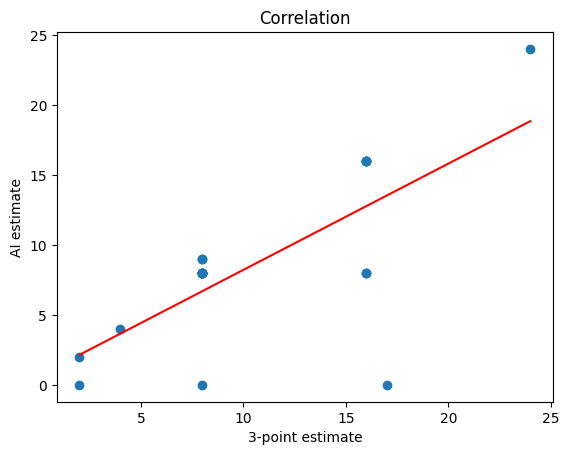

In [ ]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y = df_test['Ai_estimate']
x = df_test['Final_estimate']
correlation = y.corr(x)
correlation

# adds the title
plt.title('Correlation')

# plot the data
plt.scatter(x, y)

# fits the best fitting line to the data
plt.plot(np.unique(x),
		np.poly1d(np.polyfit(x, y, 1))
		(np.unique(x)), color='red')

# Labelling axes
plt.xlabel('3-point estimate')
plt.ylabel('AI estimate')

Text(0, 0.5, 'AI estimate')

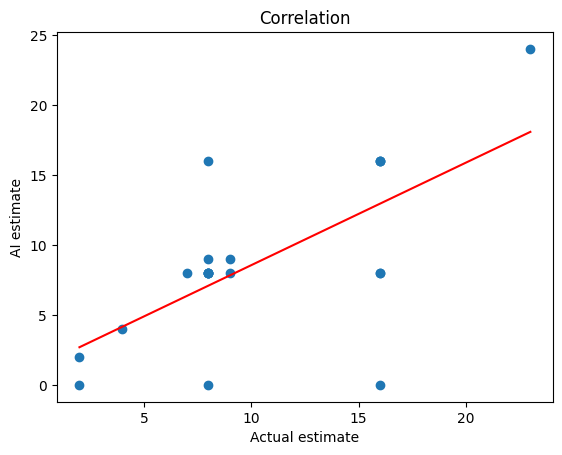

In [ ]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y = df_test['Ai_estimate']
x = df_test['Actual_estimate']
correlation = y.corr(x)
correlation

# adds the title
plt.title('Correlation')

# plot the data
plt.scatter(x, y)

# fits the best fitting line to the data
plt.plot(np.unique(x),
		np.poly1d(np.polyfit(x, y, 1))
		(np.unique(x)), color='red')

# Labelling axes
plt.xlabel('Actual estimate')
plt.ylabel('AI estimate')